# A guide Portfolio Optimization Environment

This notebook aims to provide an example of using PortfolioOptimizationEnv (or POE) to train a reinforcement learning model that learns to solve the portfolio optimization problem.

In this document, we will reproduce a famous architecture called EIIE (ensemble of identical independent evaluators), introduced in the following paper:

- Zhengyao Jiang, Dixing Xu, & Jinjun Liang. (2017). A Deep Reinforcement Learning Framework for the Financial Portfolio Management Problem. https://doi.org/10.48550/arXiv.1706.10059.

It's advisable to read it to understand the algorithm implemented in this notebook.

### Note
If you're using this environment, consider citing the following paper (in adittion to FinRL references):

- Caio Costa, & Anna Costa (2023). POE: A General Portfolio Optimization Environment for FinRL. In *Anais do II Brazilian Workshop on Artificial Intelligence in Finance* (pp. 132–143). SBC. https://doi.org/10.5753/bwaif.2023.231144.

```
@inproceedings{bwaif,
 author = {Caio Costa and Anna Costa},
 title = {POE: A General Portfolio Optimization Environment for FinRL},
 booktitle = {Anais do II Brazilian Workshop on Artificial Intelligence in Finance},
 location = {João Pessoa/PB},
 year = {2023},
 keywords = {},
 issn = {0000-0000},
 pages = {132--143},
 publisher = {SBC},
 address = {Porto Alegre, RS, Brasil},
 doi = {10.5753/bwaif.2023.231144},
 url = {https://sol.sbc.org.br/index.php/bwaif/article/view/24959}
}

```

## Installation and imports

To run this notebook in google colab, uncomment the cells below.

In [1]:
# # install finrl library
# !sudo apt install swig
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

In [2]:
## We also need to install quantstats, because the environment uses it to plot graphs
# !pip install quantstats

In [3]:
## Hide matplotlib warnings
# import warnings
# warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

#### Import the necessary code libraries

In [4]:
import torch

import numpy as np

from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Fetch data

In his paper, *Jiang et al* creates a portfolio composed by the top-11 cryptocurrencies based on 30-days volume. Since it's not specified when this classification was done, it's difficult to reproduce, so we will use a similar approach in the Brazillian stock market:

- We select top-10 stocks from Brazillian stock market;
- For simplicity, we disconsider stocks that have missing data for the days in period 2011-01-01 to 2019-12-31 (9 years);

In [14]:
TOP_BRL = [
    "VALE3.SA", "PETR4.SA", "ITUB4.SA", "BBDC4.SA",
    "BBAS3.SA", "RENT3.SA", "LREN3.SA", "PRIO3.SA",
    "WEGE3.SA", "ABEV3.SA"
]

In [15]:
print(len(TOP_BRL))

portfolio_raw_df = YahooDownloader(start_date = '2018-01-01',
                                end_date = '2024-10-22',
                                ticker_list = TOP_BRL).fetch_data()
portfolio_raw_df

10


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (16920, 8)


,date,open,high,low,close,volume,tic,day
0,2018-01-02,21.330000,21.750000,21.170000,17.242149,12717900,ABEV3.SA,1
1,2018-01-02,16.045000,16.465000,16.045000,10.688824,18356200,BBAS3.SA,1
2,2018-01-02,19.380507,19.807390,19.363432,13.985100,14794320,BBDC4.SA,1
3,2018-01-02,28.533333,29.253332,28.533333,22.512011,16650900,ITUB4.SA,1
4,2018-01-02,29.319921,29.475704,28.622999,24.728971,2772870,LREN3.SA,1
...,...,...,...,...,...,...,...,...
16915,2024-10-21,37.000000,37.049999,36.200001,36.250000,28390000,PETR4.SA,0
16916,2024-10-21,42.799999,42.889999,41.540001,41.919998,7677200,PRIO3.SA,0
16917,2024-10-21,42.490002,42.900002,42.320000,42.520000,5446300,RENT3.SA,0
16918,2024-10-21,61.349998,61.380001,60.270000,60.330002,19044900,VALE3.SA,0


In [16]:
portfolio_raw_df.groupby("tic").count()

,date,open,high,low,close,volume,day
tic,,,,,,,
ABEV3.SA,1692,1692,1692,1692,1692,1692,1692
BBAS3.SA,1692,1692,1692,1692,1692,1692,1692
BBDC4.SA,1692,1692,1692,1692,1692,1692,1692
ITUB4.SA,1692,1692,1692,1692,1692,1692,1692
LREN3.SA,1692,1692,1692,1692,1692,1692,1692
PETR4.SA,1692,1692,1692,1692,1692,1692,1692
PRIO3.SA,1692,1692,1692,1692,1692,1692,1692
RENT3.SA,1692,1692,1692,1692,1692,1692,1692
VALE3.SA,1692,1692,1692,1692,1692,1692,1692


### Normalize Data

We normalize the data dividing the time series of each stock by its maximum value, so that the dataframe contains values between 0 and 1.

In [17]:
portfolio_norm_df = GroupByScaler(by="tic", scaler=MaxAbsScaler).fit_transform(portfolio_raw_df)
portfolio_norm_df

/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.08828043 0.06517935 0.06351479 ... 0.12679844 0.13482273 0.2004505 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(
/Users/pu17/miniconda3/envs/finrobot/lib/python3.10/site-packages/finrl/meta/preprocessor/preprocessors.py:101: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.25 0.5  0.75 ... 0.75 1.   0.  ]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X.loc[select_mask, self.columns] = self.scalers[value].transform(


,date,open,high,low,close,volume,tic,day
0,2018-01-02,0.874539,0.885586,0.880982,0.890846,0.088280,ABEV3.SA,0.25
1,2018-01-02,0.538694,0.549658,0.543346,0.367821,0.089950,BBAS3.SA,0.25
2,2018-01-02,0.651400,0.660081,0.660500,0.624528,0.029636,BBDC4.SA,0.25
3,2018-01-02,0.737867,0.735193,0.743056,0.605450,0.103634,ITUB4.SA,0.25
4,2018-01-02,0.534337,0.536647,0.528323,0.510338,0.015636,LREN3.SA,0.25
...,...,...,...,...,...,...,...,...
16915,2024-10-21,0.865092,0.862832,0.850564,0.915404,0.057912,PETR4.SA,0.00
16916,2024-10-21,0.829297,0.822751,0.823553,0.824223,0.047408,PRIO3.SA,0.00
16917,2024-10-21,0.577439,0.580511,0.584799,0.615386,0.065510,RENT3.SA,0.00
16918,2024-10-21,0.512103,0.509589,0.522950,0.708806,0.103767,VALE3.SA,0.00


In [18]:
df_portfolio = portfolio_norm_df[["date", "tic", "close", "high", "low"]]

df_portfolio_train = df_portfolio[(df_portfolio["date"] >= "2018-01-01") & (df_portfolio["date"] < "2022-12-31")]
df_portfolio_2020 = df_portfolio[(df_portfolio["date"] >= "2020-01-01") & (df_portfolio["date"] < "2020-12-31")]
df_portfolio_2021 = df_portfolio[(df_portfolio["date"] >= "2021-01-01") & (df_portfolio["date"] < "2021-12-31")]
df_portfolio_2022 = df_portfolio[(df_portfolio["date"] >= "2022-01-01") & (df_portfolio["date"] < "2022-12-31")]

### Instantiate Environment

Using the `PortfolioOptimizationEnv`, it's easy to instantiate a portfolio optimization environment for reinforcement learning agents. In the example below, we use the dataframe created before to start an environment.

In [19]:
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=50,
        features=["close", "high", "low"],
        normalize_df=None
    )

### Instantiate Model

Now, we can instantiate the model using FinRL API. In this example, we are going to use the EIIE architecture introduced by Jiang et. al.

:exclamation: **Note:** Remember to set the architecture's `time_window` parameter with the same value of the environment's `time_window`.

In [20]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": 0.01,
    "policy": EIIE,
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": 3,
    "time_window": 50,
}

model = DRLAgent(environment).get_model("pg", device, model_kwargs, policy_kwargs)

### Train Model

In [21]:
DRLAgent.train_model(model, episodes=40)

  0%|          | 0/40 [00:00<?, ?it/s]

Initial portfolio value:100000
Final portfolio value: 267419.09375
Final accumulative portfolio value: 2.6741909375
Maximum DrawDown: -0.44892071243253373
Sharpe ratio: 0.8880316791447026


  2%|▎         | 1/40 [00:04<02:52,  4.42s/it]

Initial portfolio value:100000
Final portfolio value: 529086.6875
Final accumulative portfolio value: 5.290866875
Maximum DrawDown: -0.5195923536378092
Sharpe ratio: 1.3612273860992739


  5%|▌         | 2/40 [00:08<02:38,  4.17s/it]

...

 95%|█████████▌| 38/40 [02:37<00:08,  4.20s/it]

Initial portfolio value:100000
Final portfolio value: 3532930.0
Final accumulative portfolio value: 35.3293
Maximum DrawDown: -0.4763678012428787
Sharpe ratio: 1.6939434083960239


 98%|█████████▊| 39/40 [02:41<00:04,  4.17s/it]

Initial portfolio value:100000
Final portfolio value: 3598863.5
Final accumulative portfolio value: 35.988635
Maximum DrawDown: -0.4551651616780972
Sharpe ratio: 1.7042879986246735


100%|██████████| 40/40 [02:45<00:00,  4.14s/it]


### Save Model

In [22]:
torch.save(model.train_policy.state_dict(), "policy_EIIE.pt")

## Test Model

### Instantiate different environments

Since we have three different periods of time, we need three different environments instantiated to simulate them.

In [23]:
environment_2020 = PortfolioOptimizationEnv(
    df_portfolio_2020,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

environment_2021 = PortfolioOptimizationEnv(
    df_portfolio_2021,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

environment_2022 = PortfolioOptimizationEnv(
    df_portfolio_2022,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=["close", "high", "low"],
    normalize_df=None
)

### Test EIIE architecture
Now, we can test the EIIE architecture in the three different test periods. It's important no note that, in this code, we load the saved policy even though it's not necessary just to show how to save and load your model.

In [30]:
EIIE_results = {
    "training": environment._asset_memory["final"],
    "2020": {},
    "2021": {},
    "2022": {}
}

# instantiate an architecture with the same arguments used in training
# and load with load_state_dict.
policy = EIIE(time_window=50, device=device)
policy.load_state_dict(torch.load("policy_EIIE.pt"))

# 2020
DRLAgent.DRL_validation(model, environment_2020, policy=policy)
EIIE_results["2020"]["value"] = environment_2020._asset_memory["final"]

# 2021
DRLAgent.DRL_validation(model, environment_2021, policy=policy)
EIIE_results["2021"]["value"] = environment_2021._asset_memory["final"]

# 2022
DRLAgent.DRL_validation(model, environment_2022, policy=policy)
EIIE_results["2022"]["value"] = environment_2022._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 491180.0
Final accumulative portfolio value: 4.9118
Maximum DrawDown: -0.3359874849335197
Sharpe ratio: 2.6298130410463014
Initial portfolio value:100000
Final portfolio value: 94648.5703125
Final accumulative portfolio value: 0.946485703125
Maximum DrawDown: -0.14782122026400824
Sharpe ratio: -0.2651151057361862
Initial portfolio value:100000
Final portfolio value: 110264.0
Final accumulative portfolio value: 1.10264
Maximum DrawDown: -0.17463058304171653
Sharpe ratio: 0.679042942930016


In [31]:
for i, action in enumerate(environment_2021._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        print(f"Action at step {i}: {action}")

Action at step 0: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Action at step 1: [0.38682365 0.05181421 0.14059393 0.03759998 0.07726085 0.03601393
 0.07803898 0.16005656 0.00734956 0.01299294 0.01145536]
Action at step 2: [0.36060894 0.05395662 0.1529687  0.03802861 0.08116848 0.0394762
 0.08869111 0.15248747 0.00804615 0.01086622 0.01370152]
Action at step 3: [0.35621673 0.05578015 0.15518369 0.03825184 0.08101611 0.04496757
 0.09965128 0.13350968 0.00952378 0.00910193 0.01679732]
Action at step 4: [0.35478866 0.05692527 0.15483956 0.03802087 0.07802898 0.0504949
 0.11160303 0.11676472 0.01116698 0.0074302  0.0199368 ]
Action at step 5: [0.35511914 0.05686245 0.15325056 0.03772587 0.07367226 0.05570846
 0.12306679 0.10263511 0.01281039 0.00600415 0.02314482]
Action at step 6: [0.35557467 0.05582312 0.15153772 0.03748062 0.06894737 0.06045931
 0.13411804 0.09035145 0.01441758 0.00487591 0.02641416]
Action at step 7: [0.35515293 0.05413719 0.15081973 0.03743686 0.06457558 0.0644083
 0.14485317 0

### Test Uniform Buy and Hold
For comparison, we will also test the performance of a uniform buy and hold strategy. In this strategy, the portfolio has no remaining cash and the same percentage of money is allocated in each asset.

In [25]:
UBAH_results = {
    "train": {},
    "2020": {},
    "2021": {},
    "2022": {}
}

PORTFOLIO_SIZE = len(TOP_BRL)

# train period
terminated = False
environment.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment.step(action)
UBAH_results["train"]["value"] = environment._asset_memory["final"]

# 2020
terminated = False
environment_2020.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2020.step(action)
UBAH_results["2020"]["value"] = environment_2020._asset_memory["final"]

# 2021
terminated = False
environment_2021.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2021.step(action)
UBAH_results["2021"]["value"] = environment_2021._asset_memory["final"]

# 2022
terminated = False
environment_2022.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _ = environment_2022.step(action)
UBAH_results["2022"]["value"] = environment_2022._asset_memory["final"]

Initial portfolio value:100000
Final portfolio value: 242192.125
Final accumulative portfolio value: 2.42192125
Maximum DrawDown: -0.4819274410757609
Sharpe ratio: 0.7664543137279012
Initial portfolio value:100000
Final portfolio value: 170950.265625
Final accumulative portfolio value: 1.70950265625
Maximum DrawDown: -0.25078921875000004
Sharpe ratio: 1.7098057682329453
Initial portfolio value:100000
Final portfolio value: 95725.890625
Final accumulative portfolio value: 0.95725890625
Maximum DrawDown: -0.17293103079587846
Sharpe ratio: -0.15574693253056524
Initial portfolio value:100000
Final portfolio value: 113682.40625
Final accumulative portfolio value: 1.1368240625
Maximum DrawDown: -0.1666010705241745
Sharpe ratio: 0.8211963529698502


In [29]:
for i, action in enumerate(environment_2021._actions_memory):
    if not np.isnan(action).all():  # 如果 action 中不全是 NaN
        print(f"Action at step {i}: {action}")

Action at step 0: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Action at step 1: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 2: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 3: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 4: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 5: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 6: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 7: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 8: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 9: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 10: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 11: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 12: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 13: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 14: [0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Action at step 15: [0.  0.1 0.1 0.1 0.1 0.1 0.

### Plot graphics

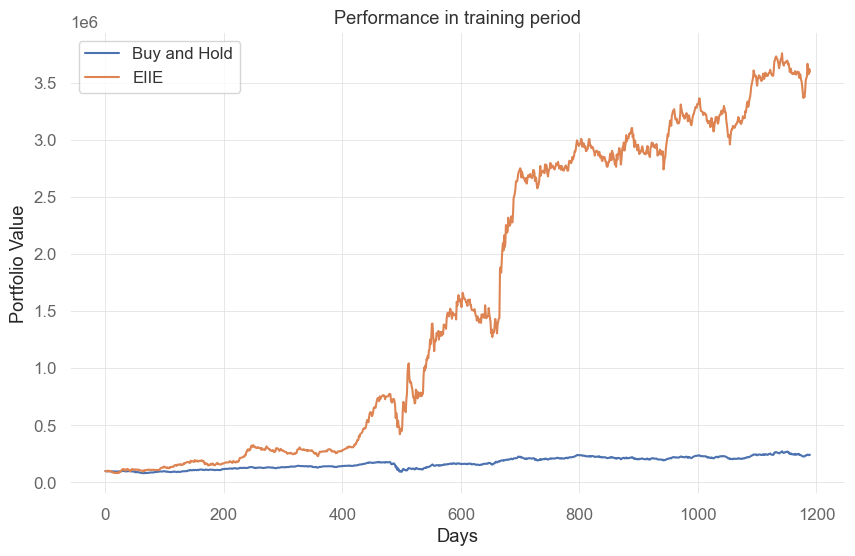

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline 

plt.plot(UBAH_results["train"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["training"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in training period")
plt.legend()

plt.show()

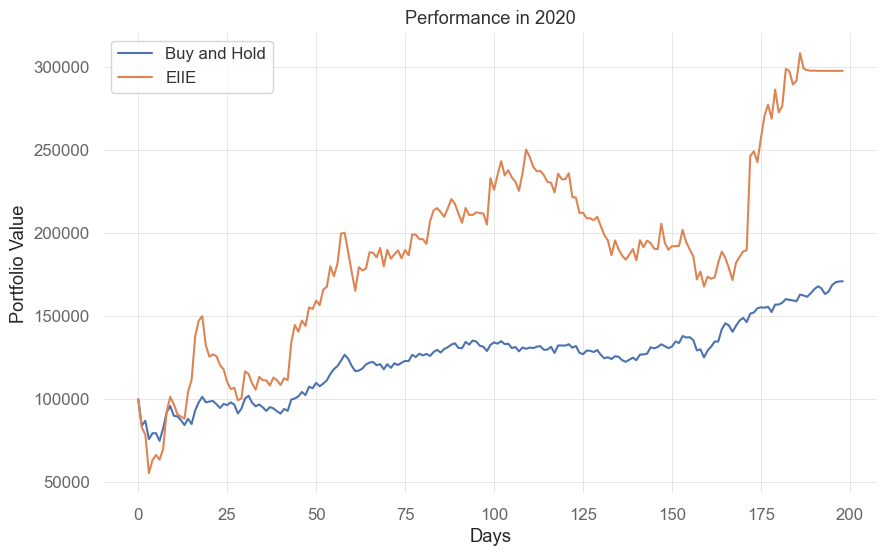

In [20]:
plt.plot(UBAH_results["2020"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2020"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2020")
plt.legend()

plt.show()

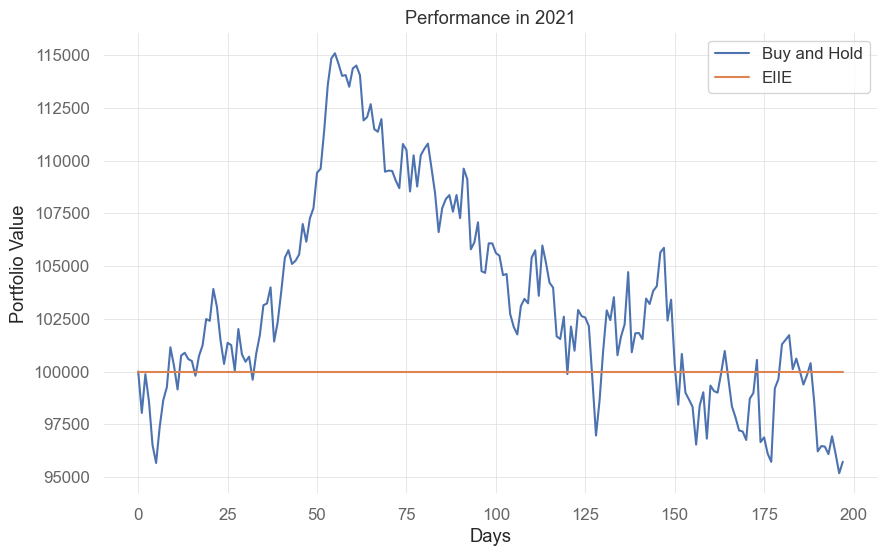

In [21]:
plt.plot(UBAH_results["2021"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2021"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2021")
plt.legend()

plt.show()

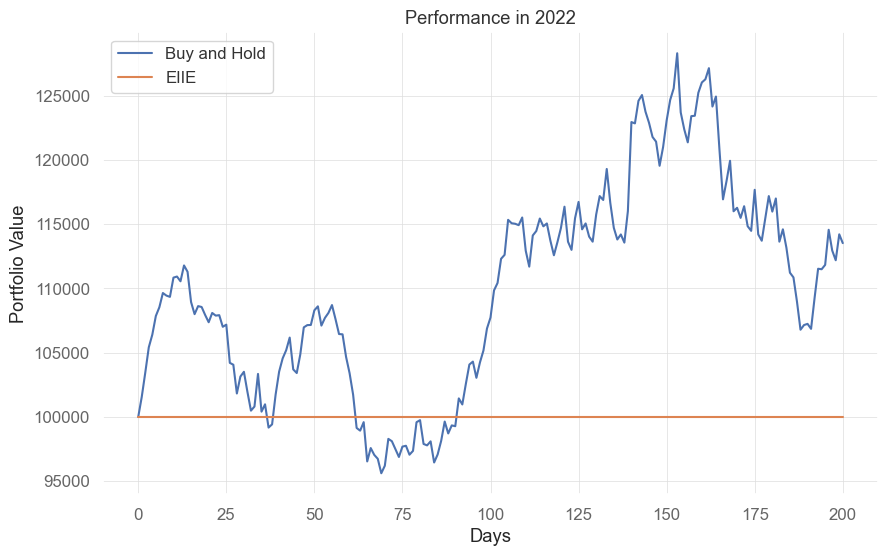

In [22]:
plt.plot(UBAH_results["2022"]["value"], label="Buy and Hold")
plt.plot(EIIE_results["2022"]["value"], label="EIIE")

plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.title("Performance in 2022")
plt.legend()

plt.show()

We can see that the agent is able to learn a good policy but its performance is worse the more the test period advances into the future. To get a better performance in 2022, for example, the agent should probably be trained again using more recent data.